# 03. GAM (일반화 가법 모델)

선형 회귀처럼 **요인별 효과를 더하는 구조는 그대로** 두되, 각 효과를 **직선이 아닌 곡선**으로 배웁니다.

```
셀아웃 = 기본수요 + f₁(할인율) + f₂(기온) + f₃(광고스톡) + … + 오차
```

예를 들어 "기온 20°C까지는 영향이 없다가 그 이상부터 급감" 같은 패턴을 잡을 수 있습니다.
더하기 구조라 지금까지의 기여도 분해·대시보드를 그대로 쓸 수 있습니다.

여기서는 **B-스플라인 곡선 + 릿지 벌점**으로 GAM을 구현합니다(벌점이 곡선을 너무 구불구불하지 않게 잡아줌).

In [1]:
import sys, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 글꼴
from common import *
plt.rcParams["figure.dpi"] = 110
df = load_data()
y = df.sellout.values.astype(float)
print(df.shape)

(104, 8)


In [2]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import SplineTransformer, StandardScaler

decay = 0.6
t = np.arange(len(df), dtype=float)
temp_c = df.temp.values - df.temp.mean()
raw = {
    "t": t, "s1": np.sin(2*np.pi*t/52), "c1": np.cos(2*np.pi*t/52),
    "disc": df.discount_pct.values.astype(float), "promo": df.promo.values.astype(float),
    "ad": adstock(df.ad_spend.values, decay), "hol": df.holiday.values.astype(float),
    "temp": temp_c, "stock": df.stockout_days.values.astype(float),
}
spline_knots = {"t": 4, "disc": 3, "temp": 5, "ad": 5}   # 곡선으로 배울 요인
ref = {"disc": 0.0, "temp": 0.0, "ad": 0.0}               # 효과를 0으로 둘 기준점

blocks, transformers = {}, {}
for k, v in raw.items():
    if k in spline_knots:
        transformers[k] = SplineTransformer(n_knots=spline_knots[k], degree=3, extrapolation="linear").fit(v[:, None])
        blocks[k] = transformers[k].transform(v[:, None])
    else:
        blocks[k] = v[:, None]
names = list(blocks)
Xm = np.column_stack([blocks[k] for k in names])
sc = StandardScaler().fit(Xm)
m = RidgeCV(alphas=np.logspace(-3, 2, 30)).fit(sc.transform(Xm), y)
coef = m.coef_ / sc.scale_
intercept = m.intercept_ - (coef * sc.mean_).sum()
pred = intercept + Xm @ coef
print(f"α = {m.alpha_:.3f},  R² = {r2(y, pred):.3f},  MAPE = {mape(y, pred):.1f}%")

α = 9.237,  R² = 0.959,  MAPE = 2.8%


## 모델이 배운 효과 곡선

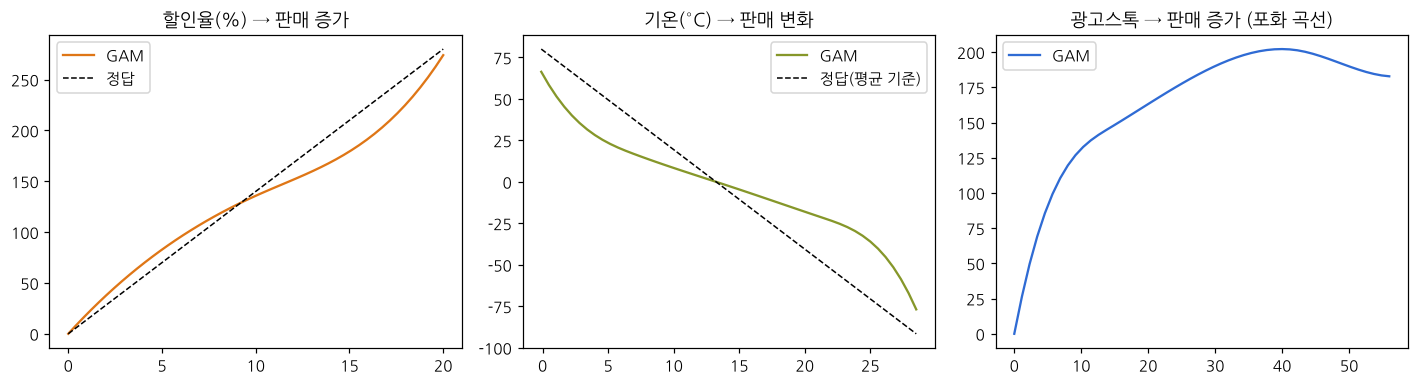

In [3]:
def curve(k, grid):
    j = sum(blocks[n].shape[1] for n in names[:names.index(k)])
    w = blocks[k].shape[1]
    B = transformers[k].transform(grid[:, None])
    r0 = transformers[k].transform(np.array([[ref[k]]])) @ coef[j:j+w]
    return B @ coef[j:j+w] - r0

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
g = np.linspace(0, 20, 50); axes[0].plot(g, curve("disc", g), color=FACTOR_COLORS["할인"], label="GAM"); axes[0].plot(g, 14*g, "k--", lw=1, label="정답")
axes[0].set_title("할인율(%) → 판매 증가"); axes[0].legend()
g = np.linspace(temp_c.min(), temp_c.max(), 50); axes[1].plot(g + df.temp.mean(), curve("temp", g), color=FACTOR_COLORS["기온"], label="GAM")
axes[1].plot(g + df.temp.mean(), -6*g, "k--", lw=1, label="정답(평균 기준)"); axes[1].set_title("기온(°C) → 판매 변화"); axes[1].legend()
g = np.linspace(0, raw["ad"].max(), 50); axes[2].plot(g, curve("ad", g), color=FACTOR_COLORS["광고"], label="GAM")
axes[2].set_title("광고스톡 → 판매 증가 (포화 곡선)"); axes[2].legend()
plt.tight_layout()

,정답,GAM
할인,14.0,13.0
프로모션,260.0,242.9
광고,52.9,51.6
공휴일,180.0,163.0
기온,-6.0,-3.3
결품,-95.0,-83.9
계절성,120.0,90.9
평균 오차율(%),NaN,15.2


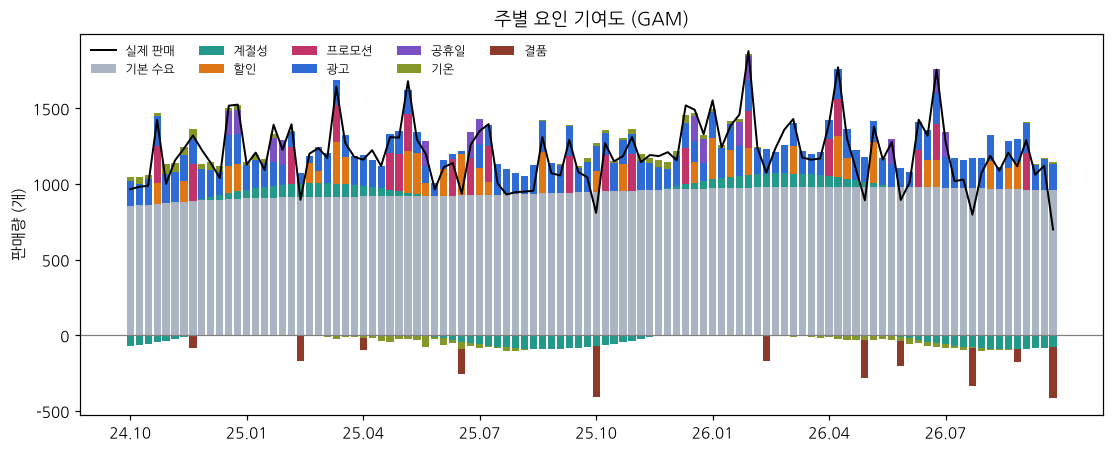

In [4]:
contrib = {f: np.zeros(len(df)) for f in FACTORS}
contrib["기본 수요"] += intercept
group = {"t": "기본 수요", "s1": "계절성", "c1": "계절성", "disc": "할인", "promo": "프로모션",
         "ad": "광고", "hol": "공휴일", "temp": "기온", "stock": "결품"}
j = 0
for k in names:
    w = blocks[k].shape[1]
    c = blocks[k] @ coef[j:j+w]
    if k in ref:
        r0 = (transformers[k].transform(np.array([[ref[k]]])) @ coef[j:j+w]).item()
        c, contrib["기본 수요"] = c - r0, contrib["기본 수요"] + r0
    contrib[group[k]] += c
    j += w
plot_stacked(df, contrib, "주별 요인 기여도 (GAM)")
effects_table({"GAM": effects(contrib, df)}, df)

## 결과 해석: 기온과 계절의 혼동

GAM은 기온 효과(정답 −6)와 계절 폭(정답 ±120)을 **둘 다 작게** 잡았습니다.
**기온도 1년 주기로 오르내리기 때문**에, 유연한 곡선 모델은 "판매가 겨울에 높은 이유"를 기온 탓으로도, 계절 탓으로도 돌릴 수 있습니다.
데이터만으로는 둘을 구분할 근거가 약해서 효과가 서로 섞입니다.

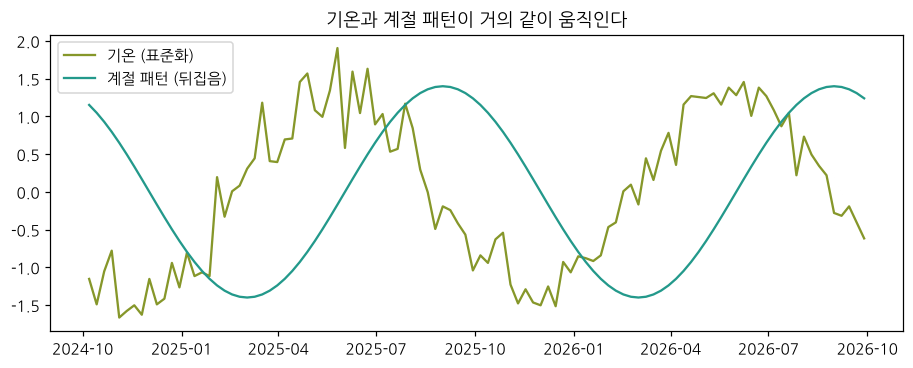

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(df.week, (df.temp - df.temp.mean()) / df.temp.std(), color=FACTOR_COLORS["기온"], label="기온 (표준화)")
ax.plot(df.week, np.sin(2*np.pi*(t-8)/52) * -1.4, color=FACTOR_COLORS["계절성"], label="계절 패턴 (뒤집음)")
ax.legend(); ax.set_title("기온과 계절 패턴이 거의 같이 움직인다");

**언제 GAM을 쓰나?**
- 효과가 직선이 아니라고 의심될 때(할인율이 일정 수준을 넘어야 효과가 나는 경우 등)
- 데이터가 충분하고, 서로 비슷하게 움직이는 요인이 적을 때

이 가상 데이터는 효과를 직선으로 만들었기 때문에 GAM의 장점이 드러나지 않았습니다. 실제 데이터에서는 다시 비교해 봐야 합니다.